# HITL basic

In [1]:
!pip install -q langgraph langchain-core

In [2]:
from google.colab import userdata
GROQ_API_KEY=userdata.get('GROQ_API_KEY')

In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.types import interrupt,Command
from langgraph.checkpoint.memory import MemorySaver

In [6]:
#state
class State(TypedDict):
    task:str
    approved:bool
    result:str


In [7]:
def human_approval(state:State):
    approval=interrupt(
        {
            'messages':"Human approval required",
            'task':state['task']
        }
    )

    return{
        'approved':approval
    }

In [8]:
def execute_task(state:State):
    if state['approved']:
        print('Executing Task')

        return{
            'result':f'task completed : {state['task']}'
        }
    else:
        print('task rejected')
        return{
            'result':'task rejected by Human'
        }

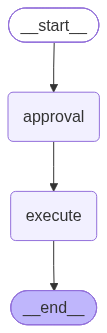

In [9]:
graph=StateGraph(State)

graph.add_node('approval',human_approval)
graph.add_node('execute',execute_task)

graph.add_edge(START,'approval')
graph.add_edge('approval','execute')
graph.add_edge('execute',END)

memory=MemorySaver()

app=graph.compile(checkpointer=memory)
app

In [12]:
config = {
    "configurable": {
        "thread_id": "user-123"
    }
}

In [13]:
inittal_state={
    'task':'Delete The database',
    'approved':False
}

response=app.invoke(inittal_state,config=config)
from rich import print
print(response)

{
    'task': 'Delete The database',
    'approved': False,
    '__interrupt__': [
        Interrupt(
            value={'messages': 'Human approval required', 'task': 'Delete The database'},
            id='daf1b0e8a7efedfa940339eea7554bf6'
        )
    ]
}

In [14]:
response

{'task': 'Delete The database',
 'approved': False,
 '__interrupt__': [Interrupt(value={'messages': 'Human approval required', 'task': 'Delete The database'}, id='daf1b0e8a7efedfa940339eea7554bf6')]}

In [17]:
response['__interrupt__'][0].value

{'messages': 'Human approval required', 'task': 'Delete The database'}

In [18]:
response=app.invoke(
    Command(resume=True),
    config=config
)

Executing Task

In [19]:
response

{'task': 'Delete The database',
 'approved': True,
 'result': 'task completed : Delete The database'}

In [22]:
config2 = {
    "configurable": {
        "thread_id": "user-1234"
    }
}

In [23]:
inittal_state={
    'task':'Delete The database',
    'approved':False
}

response=app.invoke(inittal_state,config=config2)
print(response)

{
    'task': 'Delete The database',
    'approved': False,
    '__interrupt__': [
        Interrupt(
            value={'messages': 'Human approval required', 'task': 'Delete The database'},
            id='906bc2b42b03fa79a0b152d988dad011'
        )
    ]
}

In [24]:
response=app.invoke(
    Command(resume=False),
    config=config2
)

task rejected

In [25]:
response

{'task': 'Delete The database',
 'approved': False,
 'result': 'task rejected by Human'}

#HITL With LLM

In [26]:
!pip install -q -U langgraph langchain-core langchain-groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 250.2/250.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.1/572.1 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.5/137.5 kB 10.5 MB/s eta 0:00:00


In [52]:
from typing import TypedDict

from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langchain_core.messages import HumanMessage, AIMessage, ToolMessage

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode
from langgraph.types import interrupt, Command
from langgraph.checkpoint.memory import MemorySaver

In [53]:
llm = ChatGroq(
    model="openai/gpt-oss-20b",
    api_key=GROQ_API_KEY,
    temperature=0
)

print("LLM ready!")

LLM ready!

In [90]:
@tool
def send_email(to:str,subject:str,body:str)->str:
    """
    Simulate sendening an email.This tool does not actually sending email
    """
    return{
        f'Email Successfully send to {to}\n'
        f'subject:{subject}\n'
        f'body: {body}'
    }

In [129]:
result = send_email.invoke({
    "to": "rahim@example.com",
    "subject": "Meeting Cancelled",
    "body": "Tomorrow's meeting has been cancelled."
})
result

{"Email Successfully send to rahim@example.com\nsubject:Meeting Cancelled\nbody: Tomorrow's meeting has been cancelled."}

In [130]:
tools=[send_email]
llm_with_tools=llm.bind_tools(tools)

In [131]:
from typing import Annotated
from langchain_core.messages import BaseMessage
from langgraph.graph.message import add_messages

In [163]:
class State(TypedDict):
    messages: Annotated[list, add_messages]
    approved: bool

In [133]:
def agent_node(state: State):

    response = llm_with_tools.invoke(
        state["messages"]
    )

    return {
        "messages": [response]
    }

In [164]:
def should_continue(state: State):

    last_message = state["messages"][-1]

    if isinstance(last_message, AIMessage):

        if last_message.tool_calls:
            return "human_approval"

    return END

In [165]:
def human_approval(state: State):

    last_message = state["messages"][-1]

    tool_call = last_message.tool_calls[0]

    approval = interrupt({
        "message": "Human approval required!",
        "tool_name": tool_call["name"],
        "arguments": tool_call["args"]
    })

    return {
        "approved": approval
    }

In [166]:
def approval_router(state: State):

    if state["approved"] is True:
        return "tools"

    return END

In [167]:
tool_node=ToolNode(tools)

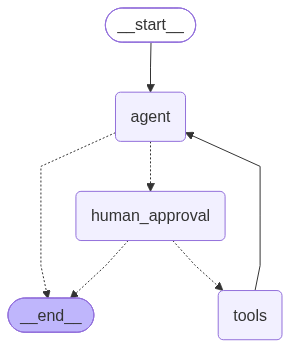

In [168]:
workflow = StateGraph(State)

# Nodes
workflow.add_node("agent", agent_node)
workflow.add_node("human_approval", human_approval)
workflow.add_node("tools", tool_node)

# START → Agent
workflow.add_edge(
    START,
    "agent"
)

# Agent → Human approval অথবা END
workflow.add_conditional_edges(
    "agent",
    should_continue,
    {
        "human_approval": "human_approval",
        END: END
    }
)

# Human approval → Tools অথবা END
workflow.add_conditional_edges(
    "human_approval",
    approval_router,
    {
        "tools": "tools",
        END: END
    }
)

# Tools → Agent
workflow.add_edge(
    "tools",
    "agent"
)

memory = MemorySaver()

app = workflow.compile(
    checkpointer=memory
)

app

In [169]:
config = {
    "configurable": {
        "thread_id": "hitl-demo-NEW-001"
    }
}

In [170]:

user_message = HumanMessage(
    content=(
        "Send an email to rahim@example.com "
        "with subject 'Meeting Cancelled' "
        "and tell him that tomorrow's meeting has been cancelled."
    )
)

result = app.invoke(
    {
        "messages": [user_message]
    },
    config=config
)


In [171]:
result['__interrupt__'][0]

Interrupt(value={'message': 'Human approval required!', 'tool_name': 'send_email', 'arguments': {'body': "Dear Rahim,\n\nI hope you are doing well. I wanted to let you know that tomorrow's meeting has been cancelled.\n\nIf you have any questions or need to reschedule, please let me know.\n\nBest regards,\n[Your Name]", 'subject': 'Meeting Cancelled', 'to': 'rahim@example.com'}}, id='da132d8495d4857834a432bda4e911db')

## Human Approval YEs

In [172]:
result = app.invoke(
    Command(resume=True),
    config=config
)

print(result)

{
    'messages': [
        HumanMessage(
            content="Send an email to rahim@example.com with subject 'Meeting Cancelled' and tell him that 
tomorrow's meeting has been cancelled.",
            additional_kwargs={},
            response_metadata={},
            id='8cc27cb0-34fb-4bb4-843d-deddc3a9a7bb'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'reasoning_content': 'We need to use the function send_email.',
                'tool_calls': [
                    {
                        'id': 'fc_ff1dede1-2f40-4768-aeb5-f3eb79a5a987',
                        'function': {
                            'arguments': '{"body":"Dear Rahim,\\n\\nI hope you are doing well. I wanted to let you 
know that tomorrow\'s meeting has been cancelled.\\n\\nIf you have any questions or need to reschedule, please let 
me know.\\n\\nBest regards,\\n[Your Name]","subject":"Meeting Cancelled","to":"rahim@example.com"}',
                            'name': 'send_email'
                        },
                        'type': 'function'
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 100,
                    'prompt_tokens': 161,
                    'total_tokens': 261,
                    'completion_time': 0.106369845,
                    'completion_tokens_details': {'reasoning_tokens': 10},
                    'prompt_time': 0.007807274,
                    'prompt_tokens_details': None,
                    'queue_time': 0.179150243,
                    'total_time': 0.114177119
                },
                'model_name': 'openai/gpt-oss-20b',
                'system_fingerprint': 'fp_ef00694abe',
                'service_tier': 'on_demand',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'groq'
            },
            id='lc_run--01a10537-fbe4-7a41-ae06-dbd01bdb7b56-0',
            tool_calls=[
                {
                    'name': 'send_email',
                    'args': {
                        'body': "Dear Rahim,\n\nI hope you are doing well. I wanted to let you know that tomorrow's
meeting has been cancelled.\n\nIf you have any questions or need to reschedule, please let me know.\n\nBest 
regards,\n[Your Name]",
                        'subject': 'Meeting Cancelled',
                        'to': 'rahim@example.com'
                    },
                    'id': 'fc_ff1dede1-2f40-4768-aeb5-f3eb79a5a987',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 161,
                'output_tokens': 100,
                'total_tokens': 261,
                'output_token_details': {'reasoning': 10}
            }
        ),
        ToolMessage(
            content='{"Email Successfully send to rahim@example.com\\nsubject:Meeting Cancelled\\nbody: Dear 
Rahim,\\n\\nI hope you are doing well. I wanted to let you know that tomorrow\'s meeting has been 
cancelled.\\n\\nIf you have any questions or need to reschedule, please let me know.\\n\\nBest regards,\\n[Your 
Name]"}',
            name='send_email',
            id='df1c87bd-ffcc-4a60-98b5-9698579a98d5',
            tool_call_id='fc_ff1dede1-2f40-4768-aeb5-f3eb79a5a987'
        ),
        AIMessage(
            content='✅ Email sent to rahim@example.com with subject “Meeting Cancelled”.',
            additional_kwargs={
                'reasoning_content': 'The user asked to send an email. We used the tool. The tool responded with 
success. We should respond to the user acknowledging that the email was sent.'
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 57,
                    'prompt_tokens': 331,
                    'total_tokens': 388,
         

In [173]:
for message in result["messages"]:

    print("\n---")
    print(type(message).__name__)
    print(message.content)

---

HumanMessage

Send an email to rahim@example.com with subject 'Meeting Cancelled' and tell him that tomorrow's meeting has been 
cancelled.

---

AIMessage

...

ToolMessage

{"Email Successfully send to rahim@example.com\nsubject:Meeting Cancelled\nbody: Dear Rahim,\n\nI hope you are 
doing well. I wanted to let you know that tomorrow's meeting has been cancelled.\n\nIf you have any questions or 
need to reschedule, please let me know.\n\nBest regards,\n[Your Name]"}

---

AIMessage

✅ Email sent to rahim@example.com with subject “Meeting Cancelled”.

# For NO

In [174]:
config_no = {
    "configurable": {
        "thread_id": "hitl-demo-002"
    }
}

In [175]:
user_message = HumanMessage(
    content=(
        "Send an email to karim@example.com "
        "with subject 'Important Update' "
        "and tell him that the project deadline has changed."
    )
)

result = app.invoke(
    {
        "messages": [user_message]
    },
    config=config_no
)

result["__interrupt__"][0].value

{'message': 'Human approval required!',
 'tool_name': 'send_email',
 'arguments': {'body': 'Hello Karim,\n\nI wanted to let you know that the project deadline has been changed. Please review the updated schedule and let me know if you have any questions.\n\nThank you,\n[Your Name]',
  'subject': 'Important Update',
  'to': 'karim@example.com'}}

In [176]:
result = app.invoke(
    Command(resume=False),
    config=config_no
)

print(result)

{
    'messages': [
        HumanMessage(
            content="Send an email to karim@example.com with subject 'Important Update' and tell him that the 
project deadline has changed.",
            additional_kwargs={},
            response_metadata={},
            id='5812b248-df94-4919-840a-ece4fb765205'
        ),
        AIMessage(
            content='',
            additional_kwargs={
                'reasoning_content': 'We need to use the function send_email. Provide body, subject, to.',
                'tool_calls': [
                    {
                        'id': 'fc_1e122377-4c32-4ade-b6bd-a58549195fa4',
                        'function': {
                            'arguments': '{"body":"Hello Karim,\\n\\nI wanted to let you know that the project 
deadline has been changed. Please review the updated schedule and let me know if you have any questions.\\n\\nThank
you,\\n[Your Name]","subject":"Important Update","to":"karim@example.com"}',
                            'name': 'send_email'
                        },
                        'type': 'function'
                    }
                ]
            },
            response_metadata={
                'token_usage': {
                    'completion_tokens': 95,
                    'prompt_tokens': 159,
                    'total_tokens': 254,
                    'completion_time': 0.098828344,
                    'completion_tokens_details': {'reasoning_tokens': 17},
                    'prompt_time': 0.009077909,
                    'prompt_tokens_details': None,
                    'queue_time': 0.172500235,
                    'total_time': 0.107906253
                },
                'model_name': 'openai/gpt-oss-20b',
                'system_fingerprint': 'fp_8d13edce1d',
                'service_tier': 'on_demand',
                'finish_reason': 'tool_calls',
                'logprobs': None,
                'model_provider': 'groq'
            },
            id='lc_run--01a10538-222a-78c3-bf4a-c60761367d29-0',
            tool_calls=[
                {
                    'name': 'send_email',
                    'args': {
                        'body': 'Hello Karim,\n\nI wanted to let you know that the project deadline has been 
changed. Please review the updated schedule and let me know if you have any questions.\n\nThank you,\n[Your Name]',
                        'subject': 'Important Update',
                        'to': 'karim@example.com'
                    },
                    'id': 'fc_1e122377-4c32-4ade-b6bd-a58549195fa4',
                    'type': 'tool_call'
                }
            ],
            invalid_tool_calls=[],
            usage_metadata={
                'input_tokens': 159,
                'output_tokens': 95,
                'total_tokens': 254,
                'output_token_details': {'reasoning': 17}
            }
        )
    ],
    'approved': False
}

In [177]:
for message in result["messages"]:

    print("\n---")
    print(type(message).__name__)
    print(message.content)

---

HumanMessage

Send an email to karim@example.com with subject 'Important Update' and tell him that the project deadline has 
changed.

---

AIMessage

In [178]:
for message in result["messages"]:

    print("\n" + "=" * 60)
    print("TYPE:", type(message).__name__)
    print("CONTENT:", message.content)

    if isinstance(message, AIMessage):
        print("TOOL CALLS:", message.tool_calls)

============================================================

TYPE: HumanMessage

CONTENT: Send an email to karim@example.com with subject 'Important Update' and tell him that the project deadline 
has changed.

============================================================

TYPE: AIMessage

CONTENT:

TOOL CALLS:
[
    {
        'name': 'send_email',
        'args': {
            'body': 'Hello Karim,\n\nI wanted to let you know that the project deadline has been changed. Please 
review the updated schedule and let me know if you have any questions.\n\nThank you,\n[Your Name]',
            'subject': 'Important Update',
            'to': 'karim@example.com'
        },
        'id': 'fc_1e122377-4c32-4ade-b6bd-a58549195fa4',
        'type': 'tool_call'
    }
]